In [23]:
# Imports & connections
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

In [48]:
# Investigation which "type" to use for the determination of flight_duration

query_types = f"""
    SELECT
        type,
        count(*)                                                   AS events,
        count(DISTINCT flight_id)                                  AS flights,
        round(count(*)::numeric / count(DISTINCT flight_id), 2)    AS events_per_flight
    FROM fact_flight_event
    GROUP BY type
    ORDER BY events_per_flight DESC
"""

df_types = pd.read_sql(query_types, engine)

In [65]:
display(df_types.head(10))

"""
There are more flights available for entry-runway and exit-runway. Therefore, entry-runway and exit-runway are chosen for the determination of the flight duration
"""

,type,events,flights,events_per_flight
0,take-off,4420432,1406676,3.14
1,landing,4563997,1905624,2.40
2,entry-parking_position,3893715,2089804,1.86
3,exit-parking_position,3828513,2089804,1.83
4,exit-runway,32962777,24092694,1.37
5,entry-runway,32973212,24092694,1.37
6,top-of-climb,38308356,38308356,1.00
7,top-of-descent,38067420,38067420,1.00


'\nThere are more flights available for entry-runway and exit-runway. Therefore, entry-runway and exit-runway are chosen for the determination of the flight duration\n'

In [24]:
years = range(2022, 2027)
# Collect df_year in frame, to concat into one final df
frames = []                       

for year in years:
    query_flight_duration = f"""
    WITH flight_times AS (
        SELECT
            flight_id,
            MIN(event_date + event_time) FILTER (WHERE type = 'exit-runway') AS start_ts,
            MAX(event_date + event_time) FILTER (WHERE type = 'entry-runway')  AS end_ts
        FROM fact_flight_event
        WHERE type IN ('entry-runway', 'exit-runway')
          AND EXTRACT(YEAR FROM event_date) = {year}
        GROUP BY flight_id
    )
    SELECT
        ff.id        AS flight_id,
        da.name      AS airline,
        da.country   AS airline_country,
        ff.adep      AS origin,
        ff.ades      AS destination,
        ff.dof,
        ft.start_ts,
        ft.end_ts,
        ft.end_ts - ft.start_ts                            AS flight_duration,
        EXTRACT(EPOCH FROM (ft.end_ts - ft.start_ts)) / 60 AS flight_duration_minutes
    FROM flight_times ft
    INNER JOIN fact_flight ff ON ff.id   = ft.flight_id
    INNER JOIN dim_airline da ON da.icao = ff.icao_operator
    WHERE EXTRACT(YEAR FROM ff.dof) = {year}
      AND ft.start_ts IS NOT NULL
      AND ft.end_ts   IS NOT NULL
      AND ft.end_ts > ft.start_ts
    ORDER BY origin;
    """

    df_year = pd.read_sql(query_flight_duration, engine)
    frames.append(df_year)        

# concat dfs from frames into one df
df_all_years = pd.concat(frames, ignore_index=True)

In [ ]:
# do rows exist which contain both NaN in origin and destination?
beide_null = df_all_years[df_all_years["origin"].isna() & df_all_years["destination"].isna()]
len(beide_null)
# -> 0

In [38]:
# rows which contain both origin and destination
both_not_null = df_all_years[
    df_all_years["origin"].notna() & df_all_years["destination"].notna()
]
both_not_null.tail()

,flight_id,airline,airline_country,origin,destination,dof,start_ts,end_ts,flight_duration,flight_duration_minutes
1737073,-8273800290489928062,Spurling Aviation,United States,UUEE,LYBE,2026-03-07,2026-03-07 11:15:40,2026-03-07 13:53:05,0 days 02:37:25,157.416667
1737075,-72682921757482077,Spurling Aviation,United States,UUEE,LYBE,2026-02-17,2026-02-17 01:43:05,2026-02-17 04:03:50,0 days 02:20:45,140.750000
1737076,939665355632006901,Spurling Aviation,United States,UUEE,LYBE,2026-03-01,2026-03-01 11:18:55,2026-03-01 14:19:45,0 days 03:00:50,180.833333
1737077,60749230639675243,Sichuan Airlines,China,UUEE,EBBR,2026-02-17,2026-02-17 14:30:25,2026-02-17 17:51:35,0 days 03:21:10,201.166667
1737078,-4022279561339861051,Aeroflot Russian Airlines,Russia,UWSG,UUEE,2026-01-17,2026-01-17 10:35:50,2026-01-17 11:27:50,0 days 00:52:00,52.000000


<  5 min: 6.27%
< 10 min: 6.37%
< 15 min: 6.51%
< 20 min: 6.92%


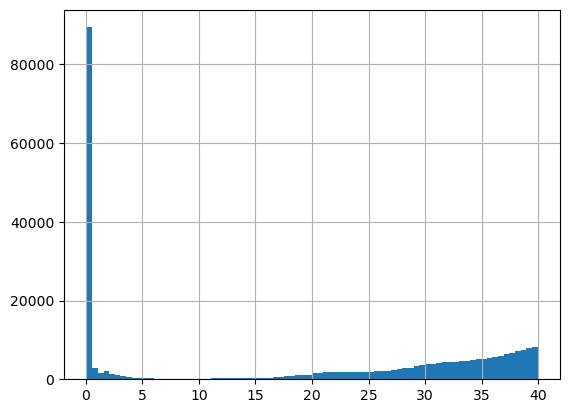

In [27]:
# how many (relative) "flight_duration_minutes" are below 20 min indicating wrong calculations
both_not_null["flight_duration_minutes"].describe(percentiles=[.01, .05, .10, .25])

# Visualisation
both_not_null.loc[both_not_null["flight_duration_minutes"] < 40, "flight_duration_minutes"].hist(bins=80)

# Data loss when setting "flight_duration_minutes" > 5, 10, 15 or 20 min
for t in (5, 10, 15, 20):
    fraction = (both_not_null["flight_duration_minutes"] < t).mean()
    print(f"< {t:>2} min: {fraction:.2%}")
# very short flights might take only 20 min
# -> sweet spot 10 min 

In [36]:
df_clean = both_not_null[
    (both_not_null["flight_duration_minutes"] >= 10) &
    (both_not_null["origin"] != both_not_null["destination"])
].copy()

In [47]:
agg = (
    df_clean
    .groupby(["origin", "destination", "airline"])
    .agg(median_min=("flight_duration_minutes", "median"),
         n=("flight_duration_minutes", "size"))
    .reset_index()
)

# Airline×route combinations for which there are at least 30 counts
agg = agg[agg["n"] >= 30]

# only routes for which there are at least 2 airlines
comparison = agg.groupby(["origin", "destination"])["airline"].transform("nunique") >= 2
agg = agg[comparison]

(agg.groupby(["origin", "destination"])["airline"].nunique()
    .sort_values(ascending=False).head(15))

origin  destination
EHAM    EDDF           11
EFHK    ESSA           10
EDDF    EHAM            9
ESSA    EFHK            8
EDDM    LSZH            8
EDDF    LEMD            8
EDDK    LOWW            8
EDDF    LSZH            8
LSZH    EDDL            7
        EDDB            7
EHAM    LEMD            7
LSZH    EDDF            7
LPPT    LEMD            7
LOWW    EDDK            7
LIMC    LEMD            7
Name: airline, dtype: int64

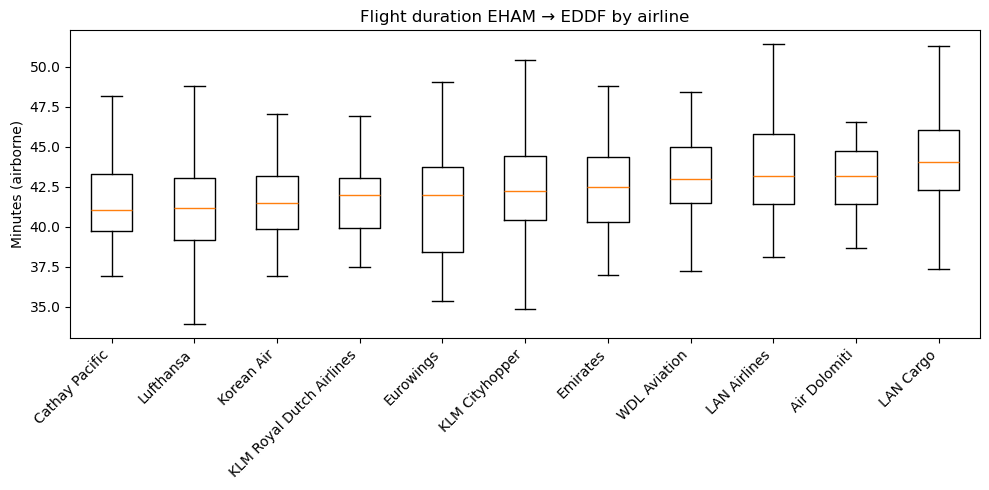

In [41]:
o, d = "EHAM", "EDDF"          # setting route (o = orgin, d = destination)
sub = df_clean[(df_clean["origin"] == o) & (df_clean["destination"] == d)]

counts = sub["airline"].value_counts()
sub = sub[sub["airline"].isin(counts[counts >= 30].index)]

order = sub.groupby("airline")["flight_duration_minutes"].median().sort_values().index
data  = [sub.loc[sub["airline"] == a, "flight_duration_minutes"] for a in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, tick_labels=order, showfliers=False)
ax.set_title(f"Flight duration {o} → {d} by airline")
ax.set_ylabel("Minutes (airborne)")
# ax.set_xlabel("Airline")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [42]:
df_all_years.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748923 entries, 0 to 1748922
Data columns (total 10 columns):
 #   Column                   Dtype          
---  ------                   -----          
 0   flight_id                object         
 1   airline                  object         
 2   airline_country          object         
 3   origin                   object         
 4   destination              object         
 5   dof                      object         
 6   start_ts                 datetime64[ns] 
 7   end_ts                   datetime64[ns] 
 8   flight_duration          timedelta64[ns]
 9   flight_duration_minutes  float64        
dtypes: datetime64[ns](2), float64(1), object(6), timedelta64[ns](1)
memory usage: 133.4+ MB


In [66]:
# Which airline did the most flights with which aircraft model within the time period 2022 - 2026?
query_fleet = """
SELECT
    da.name               AS airline,
    ff.model,
    COUNT(*)              AS n_flights
FROM fact_flight ff
INNER JOIN dim_airline da ON da.icao = ff.icao_operator
WHERE ff.model IS NOT NULL
GROUP BY da.name, ff.model
"""
fleet = pd.read_sql(query_fleet, engine)

# fleet size & diversity per airline
summary = (fleet.groupby("airline")
           .agg(distinct_models=("model", "nunique"),
                flights=("n_flights", "sum"))
           .sort_values("flights", ascending=False))

# most-flown aircraft per airline
top_model = (fleet.sort_values("n_flights", ascending=False)
                  .groupby("airline").head(1))
display(top_model)

,airline,model,n_flights
1083,Ryanair,BOEING 737-8AS,1668695
2594,Turkish Airlines,737NG 8F2/W,460114
2906,easyJet,AIRBUS A320-214,410203
729,British Airways,AIRBUS A320-232,403031
2142,Wizz Air,Airbus A321-271NX,262521
...,...,...,...
3543,Aero JBR,ATR 42-600,1
3031,Servicios Aeronauticos Integrales,ATR 72-600,1
3707,Era Helicopters,AW139,1
1787,Executive Turbine Aviation,EMB-120 ER,1


In [67]:
# Top airlines to operate on large, medium and small airports

query_apt = """
SELECT
    da.name        AS airline,
    ap_dep.type    AS dep_type,
    ap_arr.type    AS arr_type,
    COUNT(*)       AS n_flights
FROM fact_flight ff
INNER JOIN dim_airline da    ON da.icao   = ff.icao_operator
INNER JOIN dim_airport ap_dep ON ap_dep.ident = ff.adep   
INNER JOIN dim_airport ap_arr ON ap_arr.ident = ff.ades   
GROUP BY da.name, ap_dep.type, ap_arr.type
"""
ap = pd.read_sql(query_apt, engine)

top_n = 5     # how many airlines to show

# count flights grouped by airline and dep_type
dep = ap.groupby(["airline", "dep_type"])["n_flights"].sum()
arr = ap.groupby(["airline", "arr_type"])["n_flights"].sum()
dep.index = dep.index.set_names(["airline", "type"])
arr.index = arr.index.set_names(["airline", "type"])

operations = (dep.add(arr, fill_value=0)
              .astype("int64")          # add+fill_value castet sonst auf float
              .rename("touches")
              .reset_index())

# define airport types
size_types = ["large_airport", "medium_airport", "small_airport"]
operations = operations[operations["type"].isin(size_types)]

# Top airlines operating on different airport types
rankings = {}
for t in size_types:
    rankings[t] = (operations[operations["type"] == t]
                   .sort_values("touches", ascending=False)
                   .head(top_n)
                   .reset_index(drop=True)
                   .assign(rank=lambda d: d.index + 1)
                   [["rank", "airline", "touches"]])
    print(f"\n=== Top {top_n}: {t} ===")
    print(rankings[t].to_string(index=False))


=== Top 5: large_airport ===
 rank         airline  touches
    1         Ryanair  2895760
    2       Lufthansa  2153474
    3         easyJet  1567714
    4 British Airways  1145770
    5      Air France   932477

=== Top 5: medium_airport ===
 rank         airline  touches
    1         Ryanair    90563
    2    BA CityFlyer    79328
    3         easyJet    78983
    4  KLM Cityhopper    45608
    5 British Airways    37883

=== Top 5: small_airport ===
 rank                   airline  touches
    1                   Ryanair       58
    2 Arhabaev Tourism Airlines       50
    3                  Wizz Air       41
    4                 Eliossola       39
    5          Polish Air Force       36


In [68]:
# Ranking top departues and top arrival airlines per airport
airport = "EDDH"   # selected airport
top_n   = 5        # how many airlines to show

# --- departing airlines (airport = origin) ---
query_dep = f"""
SELECT da.name AS airline, COUNT(*) AS n_flights
FROM fact_flight ff
INNER JOIN dim_airline da ON da.icao = ff.icao_operator
WHERE ff.adep = '{airport}'
GROUP BY da.name
ORDER BY n_flights DESC
LIMIT {top_n}
"""

# --- arriving airlines (airport = destination) ---
query_arr = f"""
SELECT da.name AS airline, COUNT(*) AS n_flights
FROM fact_flight ff
INNER JOIN dim_airline da ON da.icao = ff.icao_operator
WHERE ff.ades = '{airport}'
GROUP BY da.name
ORDER BY n_flights DESC
LIMIT {top_n}
"""

df_dep = pd.read_sql(query_dep, engine)
df_arr = pd.read_sql(query_arr, engine)

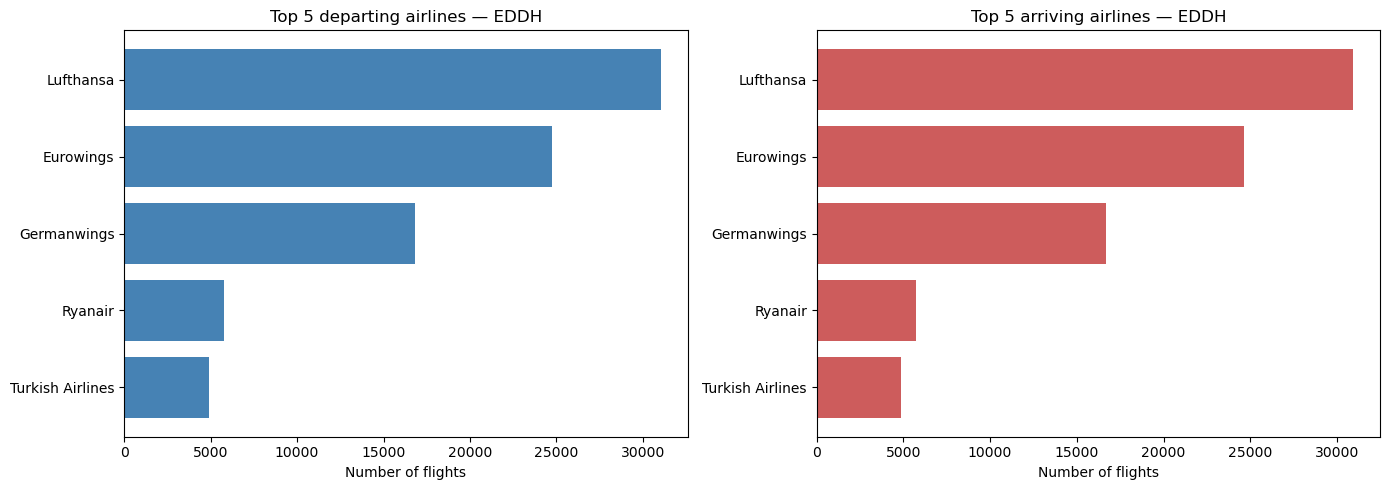

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_dep["airline"], df_dep["n_flights"], color="steelblue")
axes[0].invert_yaxis()                       # largest on top
axes[0].set_title(f"Top {top_n} departing airlines — {airport}")
axes[0].set_xlabel("Number of flights")

axes[1].barh(df_arr["airline"], df_arr["n_flights"], color="indianred")
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_n} arriving airlines — {airport}")
axes[1].set_xlabel("Number of flights")

plt.tight_layout()